# Display a map of google

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pyarrow
import pandas as pd

In [2]:
# Load roads directly from local Limburg OpenStreetMap PBF file
pbf_path = Path("../limburg-260312.osm.pbf")
if not pbf_path.exists():
    raise FileNotFoundError(f"Could not find: {pbf_path.resolve()}")

roads = gpd.read_file(pbf_path, layer="lines")

# Project for cleaner plotting in meters
roads = roads.to_crs(epsg=3857)

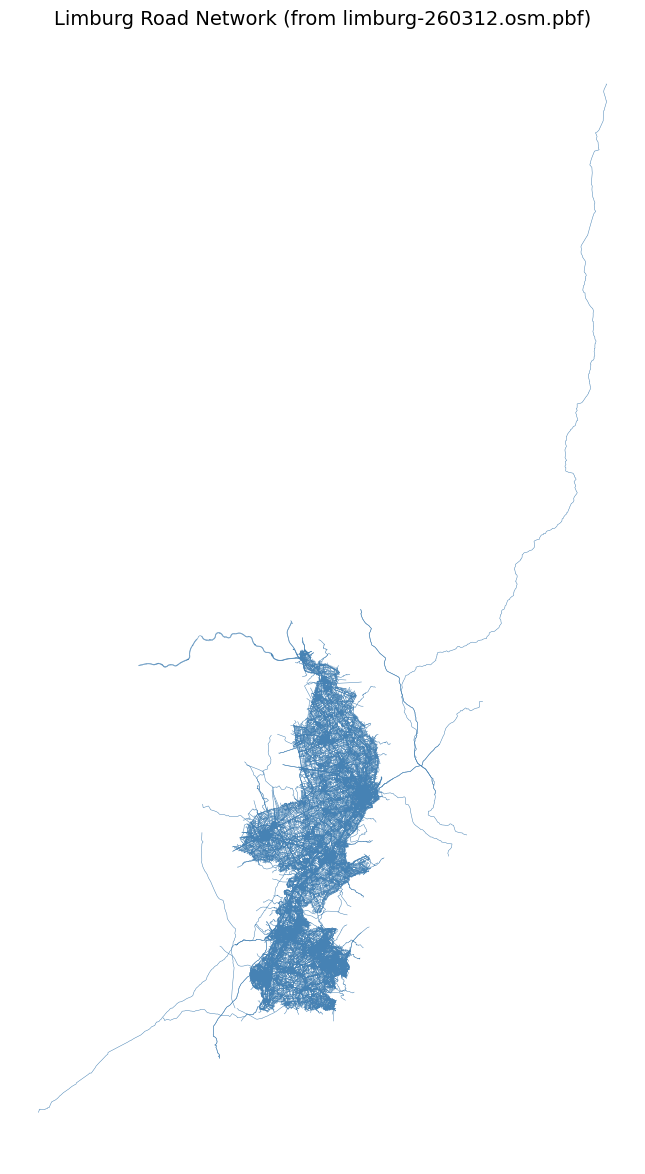

In [3]:
fig, ax = plt.subplots(figsize=(12, 12))
roads.plot(ax=ax, linewidth=0.35, color="steelblue")
ax.set_title("Limburg Road Network (from limburg-260312.osm.pbf)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

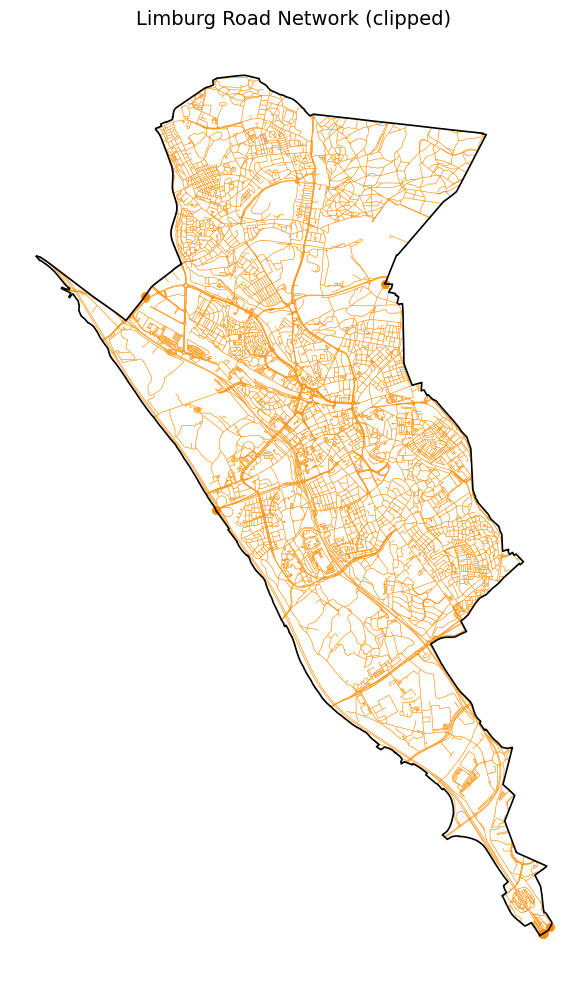

Road segments after clipping: 10,181


In [4]:
import osmnx as ox

# Build Limburg boundary and clip roads to it
limburg_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands")
limburg_boundary = limburg_boundary.to_crs(roads.crs)
limburg_geom = limburg_boundary.union_all()

# Keep road-like lines and cut segments at the Limburg border
if "highway" in roads.columns:
    roads_for_plot = roads[roads["highway"].notna()].copy()
else:
    roads_for_plot = roads.copy()

roads_limburg = gpd.clip(roads_for_plot, limburg_geom)
roads_limburg = roads_limburg[roads_limburg.geometry.notna() & ~roads_limburg.geometry.is_empty].copy()

fig, ax = plt.subplots(figsize=(10, 10))
roads_limburg.plot(ax=ax, linewidth=0.45, color="darkorange")
limburg_boundary.boundary.plot(ax=ax, linewidth=1.2, color="black")
ax.set_title("Limburg Road Network (clipped)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Road segments after clipping: {len(roads_limburg):,}")

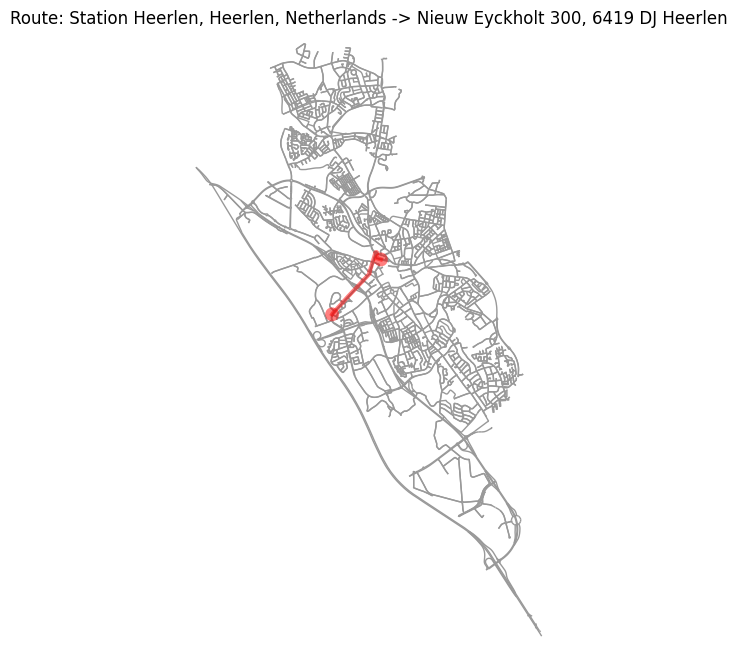

In [5]:
# Set your route endpoints here
start_point = "Station Heerlen, Heerlen, Netherlands"
destination = "Nieuw Eyckholt 300, 6419 DJ Heerlen"

# Build a drivable graph for Heerlen and geocode the two endpoints
route_graph = ox.graph_from_place("Heerlen, Limburg, Netherlands", network_type="drive")
start_lat, start_lon = ox.geocode(start_point)
end_lat, end_lon = ox.geocode(destination)

# Snap endpoints to nearest road nodes and compute shortest path by length
start_node = ox.distance.nearest_nodes(route_graph, X=start_lon, Y=start_lat)
end_node = ox.distance.nearest_nodes(route_graph, X=end_lon, Y=end_lat)
route = ox.shortest_path(route_graph, start_node, end_node, weight="length")

# Plot the route
fig, ax = ox.plot_graph_route(
    route_graph,
    route,
    route_color="red",
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
    show=False,
    close=False,
)
ax.set_title(f"Route: {start_point} -> {destination}", fontsize=12)
plt.show()

In [7]:
# Load roads directly from local Limburg OpenStreetMap PBF file
pbf_path = Path("../limburg-260312.osm.pbf")
if not pbf_path.exists():
    raise FileNotFoundError(f"Could not find: {pbf_path.resolve()}")



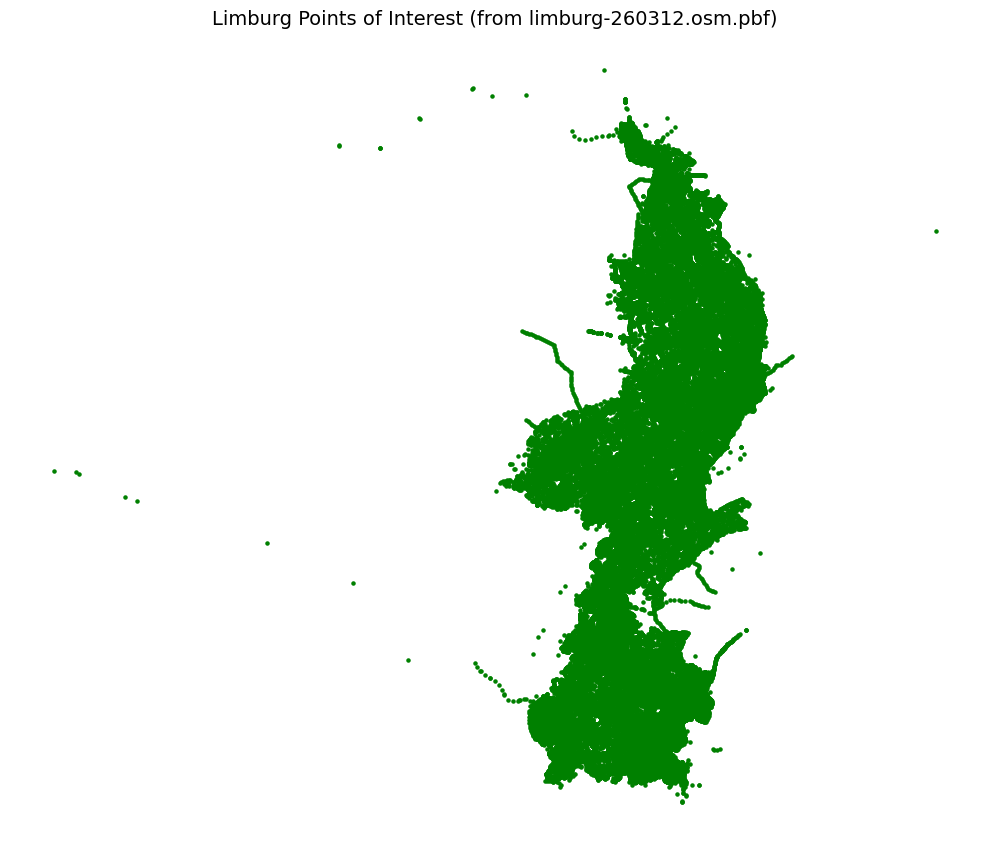

In [8]:
points = gpd.read_file(pbf_path, layer="points")

# Project for cleaner plotting in meters
points = points.to_crs(epsg=3857)

points.plot(figsize=(10, 10), color="green", markersize=5)
plt.title("Limburg Points of Interest (from limburg-260312.osm.pbf)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

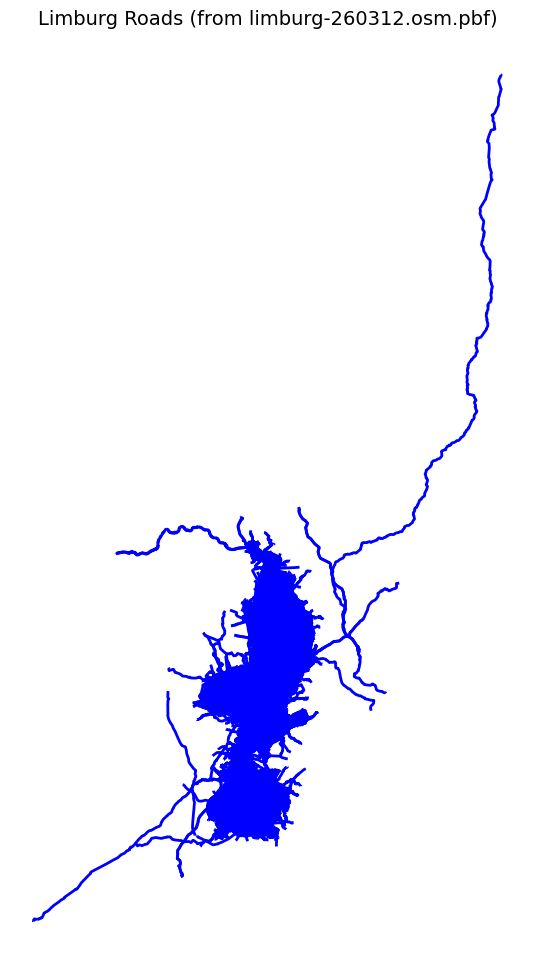

In [9]:
roads = gpd.read_file(pbf_path, layer="lines")

# Project for cleaner plotting in meters
roads = roads.to_crs(epsg=3857)

roads.plot(figsize=(10, 10), color="blue", linewidth=2)
plt.title("Limburg Roads (from limburg-260312.osm.pbf)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
roads.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,geometry
0,4443691,NaN,footway,NaN,NaN,NaN,NaN,NaN,0,"""surface""=>""paving_stones""","LINESTRING (670006.311 6578139.577, 670003.951..."


In [11]:
desired_columns = [
    "osm_id", "name", "highway", "waterway", "aerialway", 
    "barrier", "man_made", "railway", "z_order", "other_tags"
]

roads = gpd.read_file(
    pbf_path, 
    layer="lines", 
    engine="pyogrio",
    columns=desired_columns,
    use_arrow=False
)

roads_with_speed = roads[roads['other_tags'].str.contains('maxspeed', na=False)].copy()
roads_with_speed['speed_limit'] = roads_with_speed['other_tags'].str.extract(r'"maxspeed"=>"(\d+)"')

roads_with_speed = roads_with_speed[desired_columns + ['speed_limit', 'geometry']].copy()

In [12]:
roads_with_speed.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
14,4578867,Von-Byland-Straße,residential,NaN,NaN,NaN,NaN,NaN,3,"""lane_markings""=>""no"",""maxspeed""=>""30"",""zone:m...",30,"LINESTRING (5.87941 51.02503, 5.87947 51.025, ..."


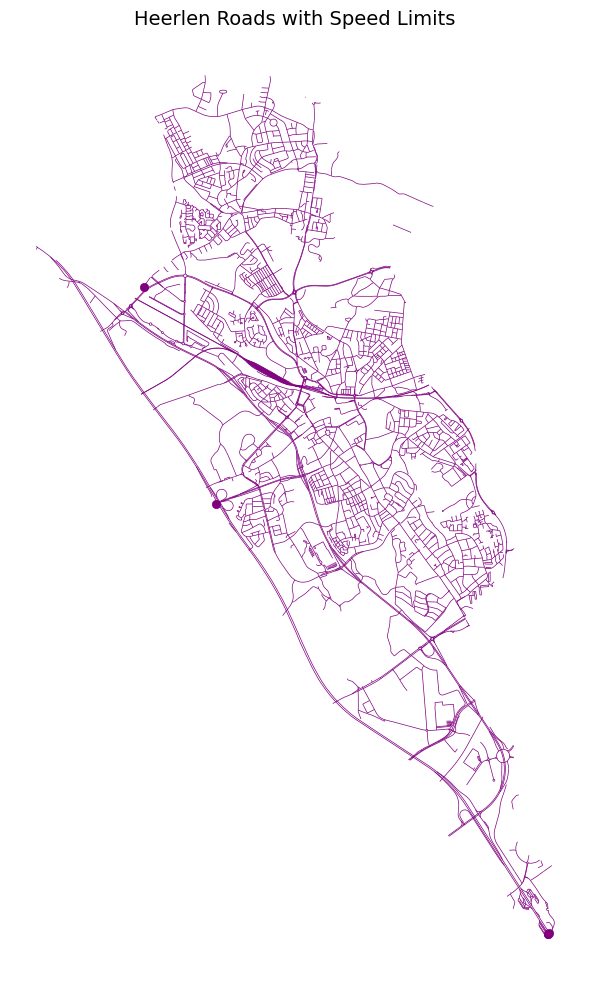

In [13]:
heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(roads_with_speed.crs)
roads_heerlen = gpd.clip(roads_with_speed, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="purple")
ax.set_title("Heerlen Roads with Speed Limits", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()



In [14]:
roads_heerlen.head(1)

,osm_id,name,highway,waterway,aerialway,barrier,man_made,railway,z_order,other_tags,speed_limit,geometry
172960,1011042634,Benzenrade,unclassified,NaN,NaN,NaN,NaN,NaN,3,"""cycleway:both""=>""no"",""lane_markings""=>""no"",""m...",60,"LINESTRING (5.97106 50.86277, 5.97115 50.86279..."


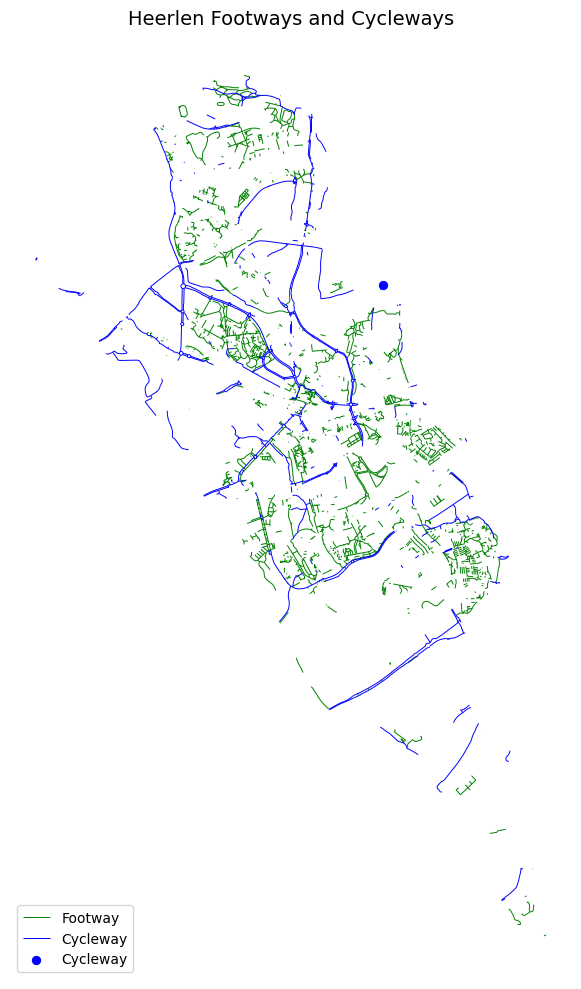

In [15]:
# Add cycleways and footways in Heerlen: footways green, cycleways blue

footway_roads = roads[roads['highway'] == 'footway'].copy()
footway_roads = footway_roads[footway_roads.geometry.notna() & ~footway_roads.geometry.is_empty].copy()

cycleway_roads = roads[roads['highway'] == 'cycleway'].copy()
cycleway_roads = cycleway_roads[cycleway_roads.geometry.notna() & ~cycleway_roads.geometry.is_empty].copy()

heerlen_geom = heerlen_boundary.geometry.iloc[0]
footway_heerlen = gpd.clip(footway_roads, heerlen_geom)
cycleway_heerlen = gpd.clip(cycleway_roads, heerlen_geom)

fig, ax = plt.subplots(figsize=(10, 10))
footway_heerlen.plot(ax=ax, linewidth=0.7, color="green", label="Footway")
cycleway_heerlen.plot(ax=ax, linewidth=0.7, color="blue", label="Cycleway")
ax.set_title("Heerlen Footways and Cycleways", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [17]:
# load in this csv clients.csv
clients = pd.read_csv("../output/clients.csv")

addresses = clients["address"].copy()
addresses.head(3)

0                       Schoolstraat 24, Heerlen
1    Laan van Hövell tot Westerflier 13, Heerlen
2                   Coriovallumstraat 7, Heerlen
Name: address, dtype: str

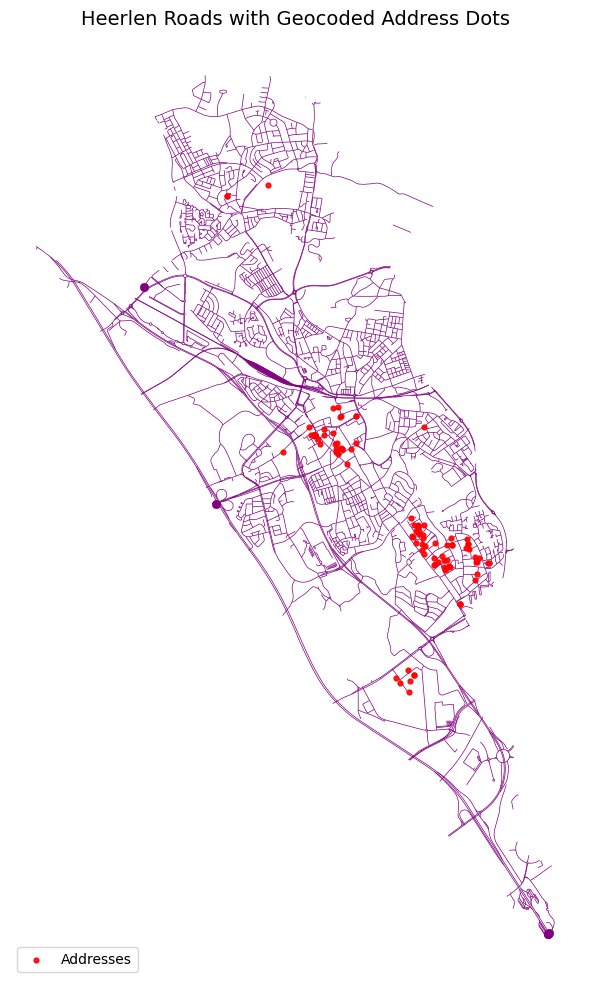

Addresses in clients.csv: 100
Geocoded successfully: 100
Failed geocoding: 0
Points inside Heerlen after clipping: 97


In [19]:
# Plot Heerlen roads and geocoded client addresses as dots
clients = pd.read_csv("../output/clients.csv")

def geocode_address(address: str):
    query = address if "netherlands" in address.lower() else f"{address}, Heerlen, Netherlands"
    try:
        lat, lon = ox.geocode(query)
        return pd.Series({"latitude": lat, "longitude": lon, "geocode_ok": True})
    except Exception:
        return pd.Series({"latitude": None, "longitude": None, "geocode_ok": False})

geocoded = clients["address"].apply(geocode_address)
clients_geocoded = pd.concat([clients, geocoded], axis=1)
clients_geocoded_ok = clients_geocoded[clients_geocoded["geocode_ok"]].copy()

address_points = gpd.GeoDataFrame(
    clients_geocoded_ok,
    geometry=gpd.points_from_xy(clients_geocoded_ok["longitude"], clients_geocoded_ok["latitude"]),
    crs="EPSG:4326",
)

heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(roads_with_speed.crs)
roads_heerlen = gpd.clip(roads_with_speed, heerlen_boundary.geometry.iloc[0])

address_points = address_points.to_crs(roads_with_speed.crs)
address_points_heerlen = gpd.clip(address_points, heerlen_boundary.geometry.iloc[0])

fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="purple")
address_points_heerlen.plot(
    ax=ax,
    color="red",
    markersize=12,
    alpha=0.9,
    zorder=3,
    label="Addresses",
)

ax.set_title("Heerlen Roads with Geocoded Address Dots", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Addresses in clients.csv: {len(clients)}")
print(f"Geocoded successfully: {len(clients_geocoded_ok)}")
print(f"Failed geocoding: {len(clients) - len(clients_geocoded_ok)}")
print(f"Points inside Heerlen after clipping: {len(address_points_heerlen)}")

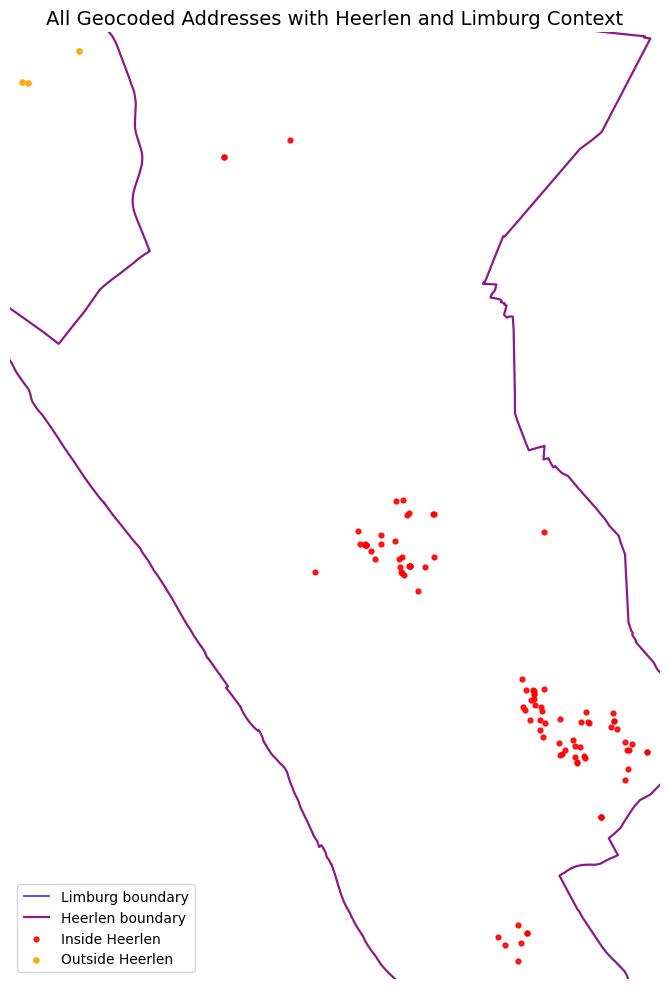

Total points: 100
Inside Heerlen: 97
Outside Heerlen: 3


In [28]:
# Show all geocoded dots with Heerlen and surrounding Limburg context

# Build Limburg province boundary in the same CRS used for plotting
limburg_boundary = ox.geocode_to_gdf("Limburg, Netherlands").to_crs(heerlen_boundary.crs)

# Split points by whether they are inside Heerlen
address_points_inside = address_points[address_points.geometry.within(heerlen_boundary.geometry.iloc[0])].copy()
address_points_outside = address_points[~address_points.geometry.within(heerlen_boundary.geometry.iloc[0])].copy()

fig, ax = plt.subplots(figsize=(10, 10))

# Context boundaries
limburg_boundary.boundary.plot(ax=ax, linewidth=1.2, color="blue", alpha=0.8, zorder=1, label="Limburg boundary")
heerlen_boundary.boundary.plot(ax=ax, linewidth=1.6, color="purple", alpha=0.9, zorder=2, label="Heerlen boundary")

# Plot all dots
if not address_points_inside.empty:
    address_points_inside.plot(
        ax=ax,
        color="red",
        markersize=12,
        alpha=0.9,
        zorder=3,
        label="Inside Heerlen",
    )

if not address_points_outside.empty:
    address_points_outside.plot(
        ax=ax,
        color="orange",
        markersize=14,
        alpha=0.95,
        zorder=4,
        label="Outside Heerlen",
    )

# Zoom to all dots (inside + outside) with tiny padding
if not address_points.empty:
    minx, miny, maxx, maxy = address_points.total_bounds
    width = max(maxx - minx, 1e-6)
    height = max(maxy - miny, 1e-6)
    pad_x = width * 0.02
    pad_y = height * 0.02
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_autoscale_on(False)

ax.set_title("All Geocoded Addresses with Heerlen and Limburg Context", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Total points: {len(address_points)}")
print(f"Inside Heerlen: {len(address_points_inside)}")
print(f"Outside Heerlen: {len(address_points_outside)}")

In [29]:
# give the list of outside heerlen
outside_addresses = address_points_outside[["address", "latitude", "longitude"]].copy()
print("Addresses outside Heerlen:")
print(outside_addresses.to_string(index=False))

Addresses outside Heerlen:
                     address  latitude  longitude
Wilhelminastraat 51, Heerlen 50.922669   5.930841
Wilhelminastraat 11, Heerlen 50.925281   5.938131
Wilhelminastraat 36, Heerlen 50.922631   5.931612
